standardization && normalization 

In [53]:
import pandas as pd 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [54]:
df =sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


feature scaling tab apply krte jab data numerica form ho 

In [55]:
df2 = df[["survived","pclass","age","parch"]]
df2.head()

,survived,pclass,age,parch
0,0,3,22.0,0
1,1,1,38.0,0
2,1,3,26.0,0
3,1,1,35.0,0
4,0,3,35.0,0


In [56]:
df3 =df2.fillna(df2.mean())  ## data clean 
df3

,survived,pclass,age,parch
0,0,3,22.000000,0
1,1,1,38.000000,0
2,1,3,26.000000,0
3,1,1,35.000000,0
4,0,3,35.000000,0
...,...,...,...,...
886,0,2,27.000000,0
887,1,1,19.000000,0
888,0,3,29.699118,2
889,1,1,26.000000,0


In [57]:
x = df3.drop("survived",axis=1)   ## survived ek target (dipend)variable h 
y = df3["survived"]
print("shape of x=" , x.shape)
print("shape of y=" , y.shape)

shape of x= (891, 3)
shape of y= (891,)


In [58]:
train_test_split(x,y,test_size=0.2 , random_state=51)

[     pclass        age  parch
 770       3  24.000000      0
 152       3  55.500000      0
 731       3  11.000000      0
 775       3  18.000000      0
 324       3  29.699118      2
 ..      ...        ...    ...
 528       3  39.000000      0
 709       3  29.699118      1
 736       3  48.000000      3
 485       3  29.699118      1
 57        3  28.500000      0
 
 [712 rows x 3 columns],
      pclass        age  parch
 30        1  40.000000      0
 429       3  32.000000      0
 534       3  30.000000      0
 633       1  29.699118      0
 416       2  34.000000      1
 ..      ...        ...    ...
 863       3  29.699118      2
 628       3  26.000000      0
 316       2  24.000000      0
 690       1  31.000000      0
 137       1  37.000000      0
 
 [179 rows x 3 columns],
 770    0
 152    0
 731    0
 775    0
 324    0
       ..
 528    0
 709    1
 736    0
 485    0
 57     0
 Name: survived, Length: 712, dtype: int64,
 30     0
 429    1
 534    0
 633    0
 416    

In [59]:
x_train,x_test ,y_train , y_test = train_test_split(x,y,test_size=0.2 , random_state=51)
print("shape of x_train=" , x_train.shape)
print("shape of x_test" , x_test.shape)
print("shape of y_train" , y_train.shape)
print("shape of y_test" , y_test.shape)

shape of x_train= (712, 3)
shape of x_test (179, 3)
shape of y_train (712,)
shape of y_test (179,)


In [60]:
sc= StandardScaler()
sc.fit(x_train)   ## function mean value std value ko learn krege  vo data copy hoke sc k ander chala gya 

StandardScaler()

In [61]:
sc.mean_          ## data ko dekhne k liya 

array([ 2.30617978, 29.55409121,  0.39185393])

In [62]:
sc.scale_

array([ 0.84405789, 12.99162985,  0.79647463])

In [63]:
x_train.describe()   ## describe ne sab kuch bta diya  mean std min count 

,pclass,age,parch
count,712.000000,712.000000,712.000000
mean,2.306180,29.554091,0.391854
std,0.844651,13.000763,0.797035
min,1.000000,0.420000,0.000000
25%,1.750000,22.000000,0.000000
50%,3.000000,29.699118,0.000000
75%,3.000000,35.000000,0.000000
max,3.000000,71.000000,5.000000


In [64]:
x_train_sc = sc.transform(x_train)
x_test_sc = sc.transform(x_test)

In [65]:
x_train_sc

array([[ 0.8220055 , -0.42751304, -0.49198545],
       [ 0.8220055 ,  1.997125  , -0.49198545],
       [ 0.8220055 , -1.42815732, -0.49198545],
       ...,
       [ 0.8220055 ,  1.41983023,  3.27461284],
       [ 0.8220055 ,  0.01116307,  0.76354731],
       [ 0.8220055 , -0.08113618, -0.49198545]])

In [66]:
x_train_sc= pd.DataFrame(x_train_sc,columns=["pclass","age",'parch'])
x_test_sc= pd.DataFrame(x_test_sc,columns=["pclass","age",'parch'])

In [67]:
x_test_sc.head()

,pclass,age,parch
0,-1.547500,0.804049,-0.491985
1,0.822005,0.188268,-0.491985
2,0.822005,0.034323,-0.491985
3,-1.547500,0.011163,-0.491985
4,-0.362747,0.342213,0.763547


In [68]:
x_train_sc.describe()

,pclass,age,parch
count,7.120000e+02,7.120000e+02,7.120000e+02
mean,1.160121e-16,1.521879e-16,6.237208e-17
std,1.000703e+00,1.000703e+00,1.000703e+00
min,-1.547500e+00,-2.242528e+00,-4.919855e-01
25%,-6.589356e-01,-5.814583e-01,-4.919855e-01
50%,8.220055e-01,1.116307e-02,-4.919855e-01
75%,8.220055e-01,4.191860e-01,-4.919855e-01
max,8.220055e-01,3.190201e+00,5.785678e+00


In [69]:
x_train_sc.describe().round(2)  # taki mean ki value zero  ho jaye

,pclass,age,parch
count,712.00,712.00,712.00
mean,0.00,0.00,0.00
std,1.00,1.00,1.00
min,-1.55,-2.24,-0.49
25%,-0.66,-0.58,-0.49
50%,0.82,0.01,-0.49
75%,0.82,0.42,-0.49
max,0.82,3.19,5.79


In [70]:
mmc = MinMaxScaler()
mmc.fit(x_train)    ## mmc learn kr chuka konsi mini ans max value 

MinMaxScaler()

In [71]:
x_train_mmc = mmc.fit_transform(x_train)
x_test_mmc = mmc.fit_transform(x_test)

In [72]:
x_train_mmc

array([[1.        , 0.33408898, 0.        ],
       [1.        , 0.78039105, 0.        ],
       [1.        , 0.14990082, 0.        ],
       ...,
       [1.        , 0.67412865, 0.6       ],
       [1.        , 0.4148359 , 0.2       ],
       [1.        , 0.39784642, 0.        ]])

In [73]:
x_train_mmc= pd.DataFrame(x_train_mmc,columns=["pclass","age",'parch'])
x_test_mmc= pd.DataFrame(x_test_mmc,columns=["pclass","age",'parch'])

In [74]:
x_train_mmc.describe().round(2)

,pclass,age,parch
count,712.00,712.00,712.00
mean,0.65,0.41,0.08
std,0.42,0.18,0.16
min,0.00,0.00,0.00
25%,0.38,0.31,0.00
50%,1.00,0.41,0.00
75%,1.00,0.49,0.00
max,1.00,1.00,1.00


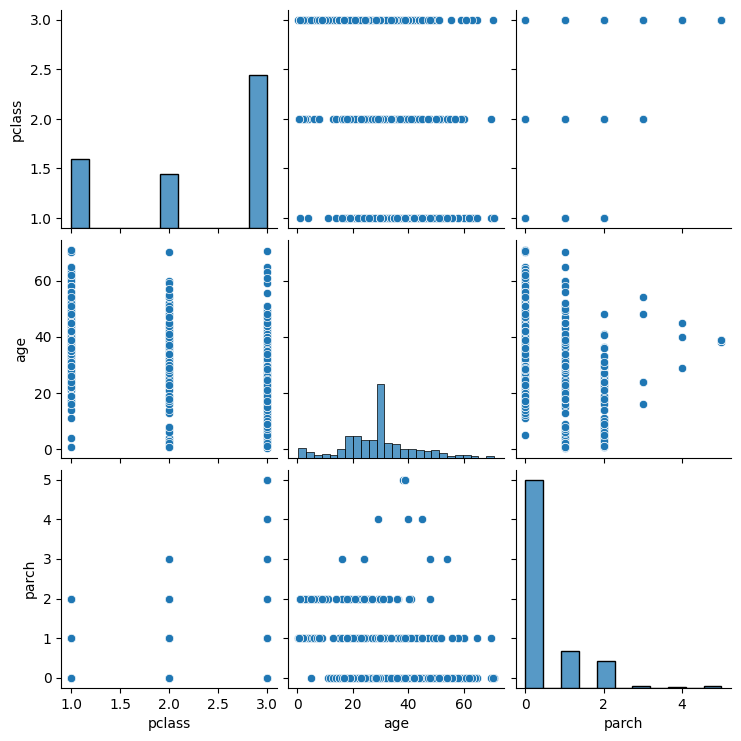

In [75]:
sns.pairplot(x_train)

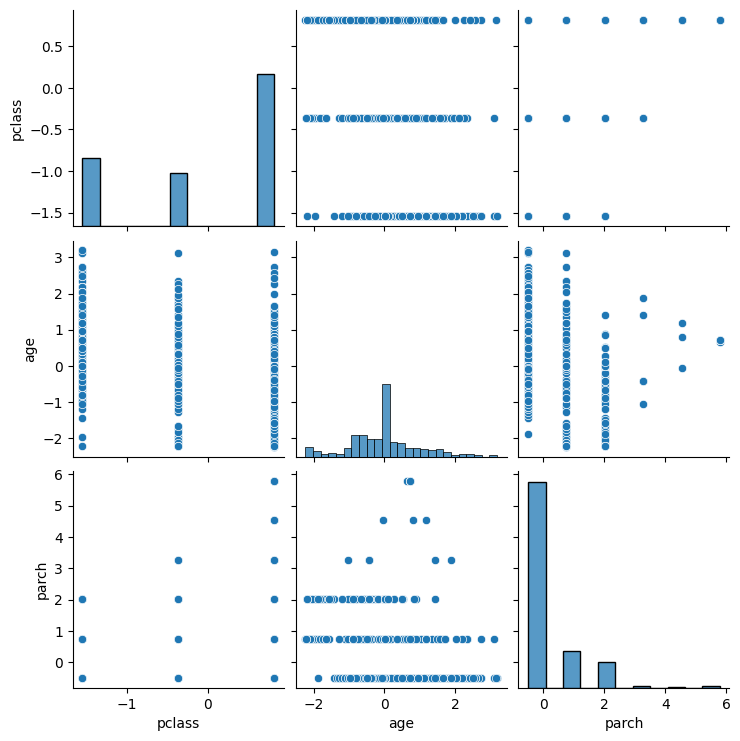

In [76]:
sns.pairplot(x_train_sc)

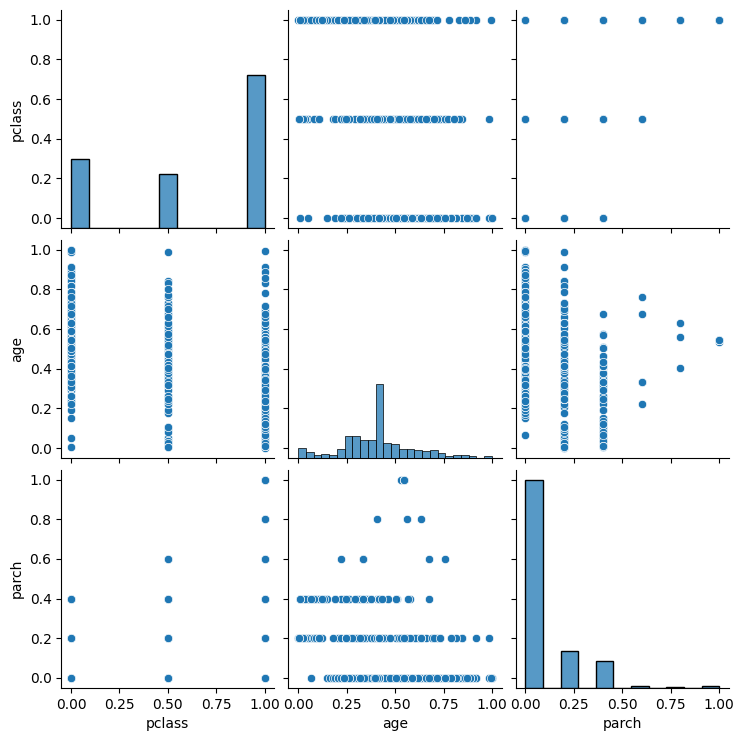

In [77]:
sns.pairplot(x_train_mmc)